# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB



Hallazgos:


 -Se observa que el data set tiene un total de 40000 registros de los cuales observamos que ninguna columna presenta nulos




 -La columna  de date es del tipo objeto y deberia ser de tipo fecha (YYYY-MM-DD)


 -La columna  de converted es de tipo int y deberia ser binaria


 -Se observan usuarios con gasto 0 los cuales deberias ser exluidos del analisis

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted']==1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['region'].value_counts())
print(df['traffic_source'].value_counts())


Conteo de categorías:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64


In [11]:

print(df['landing'].value_counts())
print(df['user_type'].value_counts())
print(df['dispositivo'].value_counts())


B    20018
A    19982
Name: landing, dtype: int64
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64


-Todas las columnas categoricas tienen valores esperados

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['converted'] == 1) & (df['landing'] == 'A')]['gasto']#completa el código
gasto_B = df[(df['converted'] == 1) & (df['landing'] == 'B')]['gasto']#completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La pagina A y B generan la misma cantidad de valor economico
- **Hipótesis alternativa (H₁):** La pagina A y B generan una cantidad diferente de valor economico

In [13]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A,gasto_B)


# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: -9.36563589591332
Valor p: 1.0635288333792346e-20


In [14]:
#Comparamos el valor P contra alpha
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")



Rechazamos la hipótesis nula: hay evidencia de una diferencia.


In [15]:
# Interpretar dirección de resultados
media_grupo_A = gasto_A.mean()
media_grupo_B = gasto_B.mean()

print('La media para A es: ', media_grupo_A)
print('La media para B es: ', media_grupo_B)
print('La diferencia es de: ', media_grupo_A - media_grupo_B)


La media para A es:  61.0865724522293
La media para B es:  68.74536005009392
La diferencia es de:  -7.658787597864624


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: hay evidencia de una diferencia

**Interpretación de negocio:**  

•	Con base en la prueba t, encontramos evidencia estadística de que el gasto promedio difiere entre las dos Paginas.


•   El gasto promedio es mayor en la Pagina B que en la Pagina A.


•	Se analizaron unicamente los usuarios que convirtieron, no todos a los usuarios a los que se les aplico la prueba.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La pagina A y B tienen la misma tasa de conversiones
- **Hipótesis alternativa (H₁):** La pagina A y B tienen diferente tasa de conversiones

In [16]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [17]:
# Pasar los valores a formato lista
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]


In [18]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)


# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22
Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: hay evidencia de una diferencia.

**Interpretación de negocio:**  
•	Con base en la prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversion entre entre las dos Paginas.


•   En particular  encontramos una mayor tasa de conversion en la Pagina B que en la Pagina A.



## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** la conversión  es independiente de la fuente de tráfico
- **Hipótesis alternativa (H₁):** la conversión depende de la fuente de tráfico

In [19]:
tabla_traffic = pd.crosstab(df['traffic_source'],df['converted'])

In [20]:
# Aplicar prueba
chi2_contingency(tabla_traffic)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_traffic)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")       #mide qué tan diferentes son los conteos observados respecto a los esperados
print(f"Valor P: {p_value:.3f}")                          #indica si la diferencia es estadísticamente significativa
print(f"Grados de libertad: {dof}")                       #los grados de libertad usados para calcular los resultados
print("\nFrecuencias esperadas:")                         #Representa cuántos casos esperaríamos en cada combinación los valores no deben ser > 5.
print(expected)



Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [21]:
#Interpretar resultados
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


In [22]:
tabla_traffic_norm = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla_traffic_norm

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

**Interpretación de negocio:**  
•	Con base en un chi-square test de independencia, encontramos evidencia estadistica de que la conversion esta asociada al tipo de fuente de trafico.


•   En particular, la fuente de trafico Email muestran una mayor tasa de conversión que los otros 3.


•   Este resultado no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** la conversión es independiente del tipo de usuario
- **Hipótesis alternativa (H₁):** la conversión depende del tipo de usuario

In [23]:
tabla_ut = pd.crosstab(df['user_type'],df['converted'])

In [24]:
# Aplicar prueba
chi2_contingency(tabla_ut)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_ut)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")       #mide qué tan diferentes son los conteos observados respecto a los esperados
print(f"Valor P: {p_value:.3f}")                          #indica si la diferencia es estadísticamente significativa
print(f"Grados de libertad: {dof}")                       #los grados de libertad usados para calcular los resultados
print("\nFrecuencias esperadas:")                         #Representa cuántos casos esperaríamos en cada combinación los valores no deben ser > 5.
print(expected)


Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [25]:
#Interpretar resultados
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.

**Interpretación de negocio:**  
•	Con base en un chi-square test de independencia, NO encontramos evidencia estadística de que la conversión está asociada al tipo de usuario.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

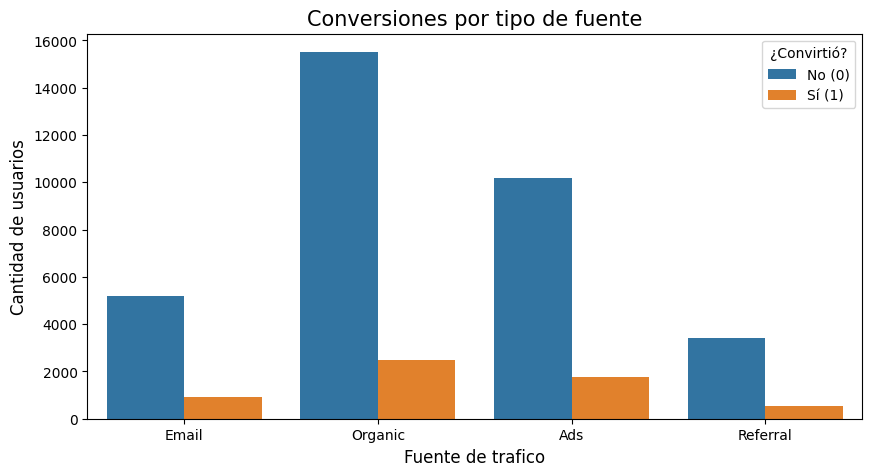

In [29]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted')

# Añadir detalles
plt.title('Conversiones por tipo de fuente', fontsize=15)
plt.xlabel('Fuente de trafico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

Como lo comprobamos en el paso 4 la fuente de trafico email muestra la mejor tasa de conversion  de entre los otros 3


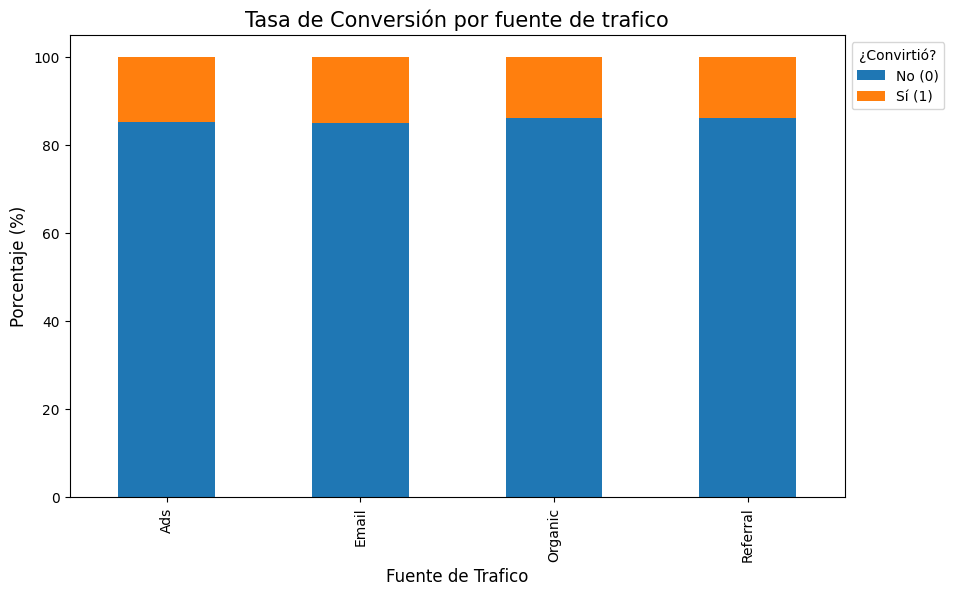

In [30]:
tabla_traffic_norm.plot(kind='bar',stacked=True, figsize=(10, 6))

plt.title('Tasa de Conversión por fuente de trafico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de Trafico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Como lo comprobamos en el paso 4 la fuente de trafico las tasas de conversion son similares porcentualmente

### Relación entre el tipo de usuario y la conversión

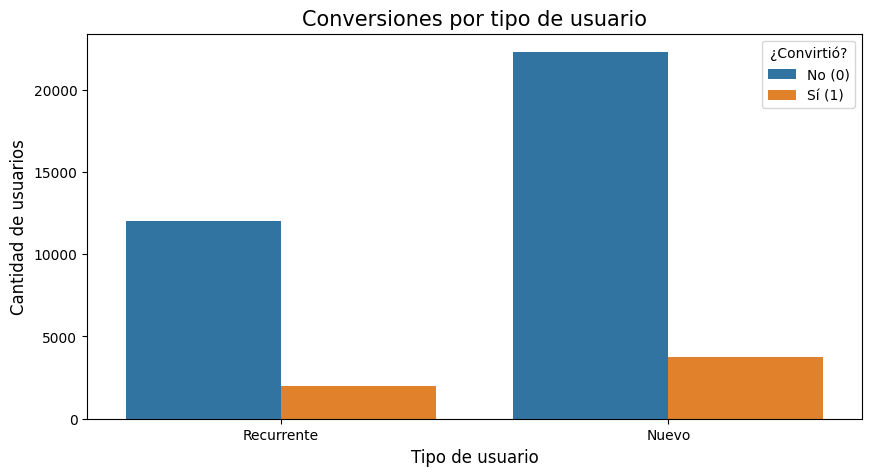

In [31]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted')

# Añadir detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


Como se demostro en el paso 5 no hay eviencia estadistica que confirme relacion entre el tipo de usuario y las conversiones

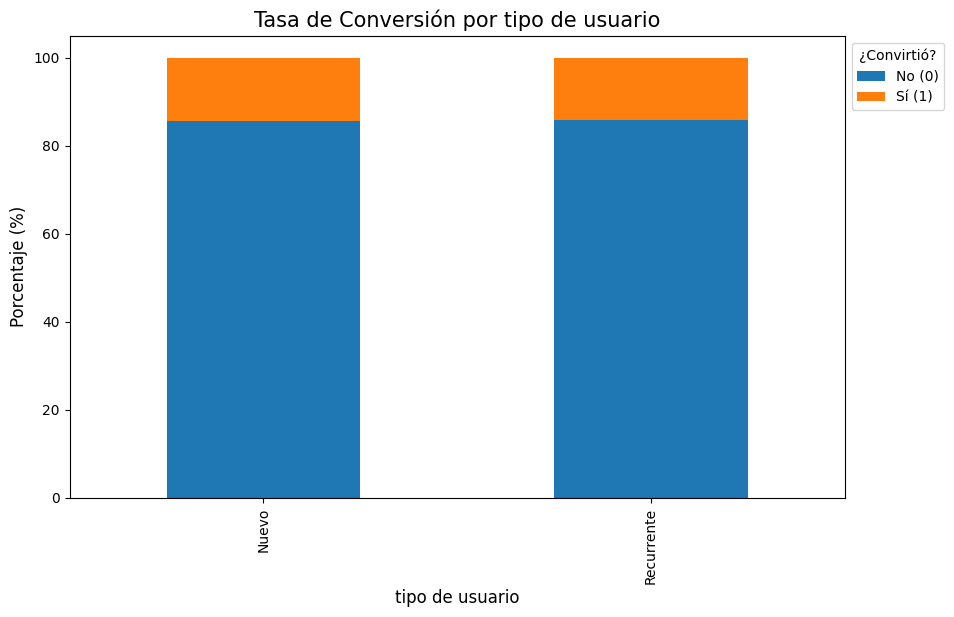

In [33]:
tabla_ut_norm = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla_ut_norm.plot(kind='bar',stacked=True, figsize=(10, 6))

plt.title('Tasa de Conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('tipo de usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Como se demostro en el paso 5 no hay eviencia estadistica que confirme relacion entre el tipo de usuario y las conversiones

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---


### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

La media para A es:  61.0865724522293

La media para B es:  68.74536005009392

La diferencia es de:  -7.658787597864624

- **Interpretación:**
  
• Con base en la prueba t, encontramos evidencia estadística de que el gasto promedio difiere entre las dos Paginas.

• El gasto promedio es mayor en la Pagina B que en la Pagina A.

• Se analizaron unicamente los usuarios que convirtieron, no todos a los usuarios a los que se les aplico la prueba.

**Tasa de conversión:** 

Tasa de conversión página A: 12.57%

Tasa de conversión página B: 15.96%


La página B tiene una mayor tasa de conversión (3.38%)

- **Interpretación:**

• Con base en la prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversion entre entre las dos Paginas.


• En particular encontramos una mayor tasa de conversion en la Pagina B que en la Pagina A.

#### 📊 **Segmentación por fuente de tráfico**

Decisión:
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.

Interpretación de negocio:

• Con base en un chi-square test de independencia, encontramos evidencia estadistica de que la conversion esta asociada al tipo de fuente de trafico.

• En particular, la fuente de trafico Email muestran una mayor tasa de conversión que los otros 3.

• Este resultado no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.

#### 📊 **Segmentación por tipo de usuario**
Decisión:
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.

Interpretación de negocio:

• Con base en un chi-square test de independencia, NO encontramos evidencia estadística de que la conversión está asociada al tipo de usuario.

• No hay diferencias significativas segun el tipo de usuario

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

#### 💡 **Recomendaciones de negocio:** 
- La pagina B muestra mejores resultados en la prueba A/B dándonos suficiente evidencia para suponer una mejor opción para conversion
- La fuente de trafico con mejor tasa durante el experimento fue el email, evaluar usarlo como medio preferente en futuros experimentos
- No vale la pena segmentar campañas por tipo de usuario, ya que no hay diferencias significativas.
